# ISIC Q1 - Resume Notebook (single GPU, resumes from checkpoints)

Slimmed re-run notebook. The base 5-fold ResNet-50 training is **not** recomputed - its checkpoints are imported from the previous run and the metrics are loaded directly. The four CMPB add-ons then run **resuming from any checkpoints** the failed run saved (Add-on 1 matched XAI, Add-on 2 ConvNeXt, Add-on 3 leakage severity, Add-on 4 natural imbalance). Everything runs on a **single GPU** for stability.

**One-time setup:** in the right sidebar click **Add Input** and attach the failed run's **Output** (the version that produced `q1_isic/checkpoints/`) *or* its results `.zip`. Then Run All. Any add-on already finished in that run is loaded from its checkpoint instead of retrained.

In [1]:
import subprocess, sys
# Add-on 1 needs Grad-CAM + LIME. --no-deps keeps the preinstalled torch/torchvision untouched.
subprocess.run([sys.executable,'-m','pip','install','-q','--no-deps','ttach','grad-cam','lime'], check=True)
print('XAI deps ready')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 68.2 MB/s eta 0:00:00
XAI deps ready


In [2]:
import warnings, os, time
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # [SINGLE-GPU] use one GPU only to avoid the multi-GPU memory crash
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from pathlib import Path
import torchvision.transforms as T
import torchvision.models as models
from sklearn.model_selection import GroupKFold, KFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from statsmodels.stats.contingency_tables import mcnemar
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [3]:
# --- [ADDED] Fast GPU sanity check -------------------------------------------
# Fails in ~1s with a clear message if the assigned GPU cannot run CUDA kernels,
# instead of crashing several minutes later during training. No modeling logic
# is changed; this only probes the device with a tiny conv+batchnorm+backward.
if DEVICE.type == 'cuda':
    try:
        _probe = nn.Sequential(nn.Conv2d(3, 8, 3), nn.BatchNorm2d(8)).to(DEVICE)
        _probe(torch.randn(2, 3, 32, 32, device=DEVICE)).sum().backward()
        torch.cuda.synchronize()
        _cap = torch.cuda.get_device_capability(0)
        print(f'GPU sanity check passed: {torch.cuda.get_device_name(0)} (sm_{_cap[0]}{_cap[1]}) | torch {torch.__version__}')
        del _probe; torch.cuda.empty_cache()
    except RuntimeError as _e:
        raise RuntimeError(
            "GPU cannot execute CUDA kernels: 'no kernel image is available for execution "
            "on the device' (cudaErrorNoKernelImageForDevice).\n"
            "This is a Kaggle accelerator/hardware<->torch mismatch, NOT a bug in this notebook.\n"
            "HOW TO FIX (right sidebar > Session options > Accelerator):\n"
            "  1) Switch accelerator to 'GPU P100' (single GPU) instead of 'GPU T4 x2' (or vice-versa).\n"
            "  2) Set Environment to 'Always use latest'.\n"
            "  3) Factory reset / restart the session, then Run All again.\n"
            f"GPU seen: {torch.cuda.get_device_name(0)} | torch {torch.__version__}\n"
            f"Original error: {_e}"
        ) from _e
else:
    print('WARNING: CUDA not available - training on CPU will be extremely slow.')

GPU sanity check passed: Tesla T4 (sm_75) | torch 2.10.0+cu128


In [4]:
IMG_SIZE=224; BATCH=32; EPOCHS=12; LR=1e-4; FOLDS=5; PATIENCE=3
SEED=42
OUT=Path('/kaggle/working/q1_isic'); OUT.mkdir(exist_ok=True)

In [5]:
# ====== [ADDED] CHECKPOINT / RESUME LAYER (safe re-run, no logic change) ======
# Saves each trained model + fold results to /kaggle/working so that if the
# kernel crashes, re-running re-loads finished steps instead of retraining.
import pickle
CKPT = OUT/'checkpoints'; CKPT.mkdir(parents=True, exist_ok=True)

def _sd(m):
    return (m.module if isinstance(m, nn.DataParallel) else m).state_dict()

def save_model_ckpt(m, tag):
    torch.save(_sd(m), CKPT/f'{tag}.pt')

def load_model_ckpt(model_fn, tag):
    p = CKPT/f'{tag}.pt'
    if not p.exists():
        return None
    m = model_fn()
    (m.module if isinstance(m, nn.DataParallel) else m).load_state_dict(torch.load(p, map_location=DEVICE))
    m.eval()
    return m

def save_pkl_ckpt(obj, tag):
    with open(CKPT/f'{tag}.pkl', 'wb') as fh:
        pickle.dump(obj, fh)

def load_pkl_ckpt(tag):
    p = CKPT/f'{tag}.pkl'
    if not p.exists():
        return None
    with open(p, 'rb') as fh:
        return pickle.load(fh)

def has_ckpt(tag):
    return (CKPT/f'{tag}.pkl').exists()

def strip_model(d):
    return {k: v for k, v in d.items() if k != 'model'}

print('Checkpoint layer ready ->', CKPT)

Checkpoint layer ready -> /kaggle/working/q1_isic/checkpoints


### Import already-done results from the failed run

In [6]:
# ====== IMPORT ALREADY-DONE RESULTS FROM THE FAILED RUN (no recompute) ======
# Pulls the base 5-fold checkpoints (orig_fold*, orig_PR_model_fold*) and any add-on
# checkpoints/outputs from the previous run so we resume instead of retraining. Attach
# that run's OUTPUT (or its results .zip) via 'Add Input' in the sidebar, then run this.
import os, glob, shutil, zipfile
CKPT.mkdir(parents=True, exist_ok=True)

def _import_from(base):
    n = 0
    for p in glob.glob(base + '/**/*', recursive=True):
        if os.path.isdir(p):
            continue
        dst = None
        if (os.sep + 'checkpoints' + os.sep) in p:
            dst = os.path.join(str(CKPT), os.path.basename(p))
        elif p.endswith(('.csv', '.png', '.zip', '.pkl', '.pt')):
            dst = os.path.join(str(OUT), os.path.basename(p))
        if dst and not os.path.exists(dst):
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            shutil.copy2(p, dst); n += 1
    return n

found = None
for base in sorted(glob.glob('/kaggle/input/*')):
    if glob.glob(base + '/**/orig_fold*.pkl', recursive=True):
        found = base; break
if found is None:
    for z in glob.glob('/kaggle/input/**/*.zip', recursive=True):
        try:
            with zipfile.ZipFile(z) as zf:
                if any('orig_fold' in nm for nm in zf.namelist()):
                    zf.extractall('/kaggle/working/_old_import'); found = '/kaggle/working/_old_import'; break
        except zipfile.BadZipFile:
            continue

assert found, ("Old results not found. Use 'Add Input' to attach the failed run's "
    "OUTPUT (with q1_isic/checkpoints/orig_fold*.pkl) or its results .zip, then re-run this cell.")
copied = _import_from(found)
_have = sorted(os.path.basename(x) for x in glob.glob(str(CKPT) + '/*'))
print(f'Imported {copied} file(s) from: {found}')
print('  base fold checkpoints :', [x for x in _have if x.startswith('orig_fold')])
print('  base model checkpoints:', [x for x in _have if x.startswith('orig_PR_model')])
print('  add-on checkpoints    :', [x for x in _have if x.startswith('addon')])

Imported 26 file(s) from: /kaggle/input/notebooks
  base fold checkpoints : ['orig_fold1.pkl', 'orig_fold2.pkl', 'orig_fold3.pkl', 'orig_fold4.pkl', 'orig_fold5.pkl']
  base model checkpoints: ['orig_PR_model_fold1.pt', 'orig_PR_model_fold2.pt', 'orig_PR_model_fold3.pt', 'orig_PR_model_fold4.pt', 'orig_PR_model_fold5.pt']
  add-on checkpoints    : ['addon1_leaky.pt', 'addon2_fold1.pkl']


In [7]:
# Auto-detect ISIC dataset path
def find_isic():
    # Recursively search all of /kaggle/input for the metadata CSV
    # for p in ['/kaggle/input' || '/kaggle/input/datasets/sumaiyabinteshahid/isic-challenge-dataset-2020/ISIC_2020_Dataset']:
    for p in ['/kaggle/input', '/kaggle/input/datasets/sumaiyabinteshahid/isic-challenge-dataset-2020/ISIC_2020_Dataset']:
        # Look for either the custom name or the official name
        csvs = list(Path(p).rglob('*Train_Metadata.csv')) + list(Path(p).rglob('train.csv'))
        if csvs: 
            # Return the folder containing the CSV, and the CSV path itself
            return csvs[0].parent, csvs[0]
            
    raise FileNotFoundError('Dataset not found. Please add the ISIC dataset.')

BASE, CSV = find_isic()
print(f'Root: {BASE}\nCSV:  {CSV}')

print('Indexing images...')
# Find all .jpg files anywhere in the dataset folder
IDX = {f.stem: str(f) for f in BASE.rglob('*.jpg')}
print(f'Indexed {len(IDX):,} images')


Root: /kaggle/input/datasets/sumaiyabinteshahid/isic-challenge-dataset-2020/ISIC_2020_Dataset
CSV:  /kaggle/input/datasets/sumaiyabinteshahid/isic-challenge-dataset-2020/ISIC_2020_Dataset/ISIC_2020_Train_Metadata.csv
Indexing images...
Indexed 44,108 images


In [8]:
def load_data():
    df = pd.read_csv(CSV)
    df['Label']      = df['target'].astype(int)  # 1 is malignant, 0 is benign
    df['Patient_ID'] = df['patient_id'].astype(str)
    df['filepath']   = df['image_name'].map(IDX)
    df = df.dropna(subset=['filepath']).reset_index(drop=True)
    # Balance dataset: ISIC is highly imbalanced, so we take all ~584 malignant cases
    # and an equal number of benign cases to create a balanced subset of ~1,168 images.
    pos=df[df.Label==1]; neg=df[df.Label==0]
    k=min(len(pos),len(neg))
    df=pd.concat([pos.sample(k,random_state=SEED),neg.sample(k,random_state=SEED)])
    df=df.sample(frac=1,random_state=SEED).reset_index(drop=True)
    print(f'{len(df)} images | {df.Patient_ID.nunique()} patients')
    print(df.Label.value_counts()); return df

isic_df = load_data()

1168 images | 802 patients
Label
0    584
1    584
Name: count, dtype: int64


In [9]:
MN=[0.485,0.456,0.406]; ST=[0.229,0.224,0.225]

BT = T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)),
                T.ToTensor(),T.Normalize(MN,ST)])
AT = T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)),
                T.RandomHorizontalFlip(0.5),
                T.RandomVerticalFlip(0.5),
                T.RandomRotation(90),
                T.ColorJitter(brightness=0.15,contrast=0.15),
                T.ToTensor(),T.Normalize(MN,ST)])

# [SPEED FIX] ISIC 2020 are FULL-RESOLUTION dermoscopy JPEGs. Re-decoding them from
# disk every epoch is the real bottleneck that made training look 'stuck'. We:
#   1) use PIL draft() for a fast approximate JPEG decode (libjpeg DCT downscale),
#   2) resize once to IMG_SIZE, and
#   3) cache the small RGB image in RAM so every later epoch/model is near-instant.
# num_workers=0 keeps ONE shared cache in the main process (persists across ALL
# models) and eliminates any DataLoader worker-fork hang.
_IMG_CACHE = {}
def _load_img(path):
    im = _IMG_CACHE.get(path)
    if im is None:
        im = Image.open(path)
        try: im.draft('RGB', (IMG_SIZE*2, IMG_SIZE*2))
        except Exception: pass
        im = im.convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        _IMG_CACHE[path] = im
    return im

class DS(Dataset):
    def __init__(self,df,aug=False): self.df=df.reset_index(drop=True); self.t=AT if aug else BT
    def __len__(self): return len(self.df)
    def __getitem__(self,i):
        r=self.df.iloc[i]
        return self.t(_load_img(r.filepath)),int(r.Label),str(r.Patient_ID)

def dl(df,aug=False,sh=True):
    return DataLoader(DS(df,aug),batch_size=BATCH,shuffle=sh,num_workers=0,pin_memory=True)

print('Dataset class ready (fast draft decode + RAM cache, single-process loader)')

Dataset class ready (fast draft decode + RAM cache, single-process loader)


In [10]:
def mkmodel():
    m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    m.fc = nn.Linear(m.fc.in_features, 2)
    m = m.to(DEVICE)
    if torch.cuda.device_count() > 1:
        print(f'  Using {torch.cuda.device_count()} GPUs via DataParallel')
        m = nn.DataParallel(m)
    return m

def evl(model,loader):
    model.eval(); yt,yp,ypr=[],[],[]; fn=nn.CrossEntropyLoss(); tl=0
    with torch.no_grad():
        for x,y,_ in loader:
            x,y=x.to(DEVICE),y.to(DEVICE); lg=model(x)
            tl+=fn(lg,y).item()
            yt.extend(y.cpu().numpy()); yp.extend(lg.argmax(1).cpu().numpy())
            ypr.extend(torch.softmax(lg,1)[:,1].cpu().numpy())
    yt,yp,ypr=map(np.array,[yt,yp,ypr])
    auc=roc_auc_score(yt,ypr) if len(np.unique(yt))>1 else 0.5
    return tl/max(len(loader),1),auc,accuracy_score(yt,yp),f1_score(yt,yp,zero_division=0),yt,yp,ypr

print('Model + evaluator ready')

Model + evaluator ready


### Load base results from checkpoints (no retraining)

In [11]:
# ====== LOAD ALREADY-COMPUTED BASE RESULTS (no retraining) ======
# Rebuild the deterministic fold splits (via SEED) and load the base ResNet-50
# patient/leaky metrics from the imported checkpoints. Add-on 2 needs PR/RR for its
# cross-architecture table; Add-on 1 needs the last rigorous model for matched XAI.
gkf = list(GroupKFold(FOLDS).split(isic_df, isic_df.Label, groups=isic_df.Patient_ID))
rkf = list(KFold(FOLDS, shuffle=True, random_state=SEED).split(isic_df))
PR, RR = [], []
mc_yt, mc_pat, mc_ran = [], [], []
_missing = []
for f in range(FOLDS):
    c = load_pkl_ckpt(f'orig_fold{f+1}')
    if c is None:
        _missing.append(f + 1); continue
    PR.append(c['PR']); RR.append(c['RR'])
    mc_yt.extend(c['PR']['yt']); mc_pat.extend(c['PR']['yp']); mc_ran.extend(c['RR']['yp'])
assert not _missing, (f'Missing base checkpoints for folds {_missing}. Make sure the failed '
    'run output (q1_isic/checkpoints) was imported by the cell above.')
# Load ONLY the last fold's rigorous model - the single model Add-on 1 XAI needs.
PR[-1]['model'] = load_model_ckpt(mkmodel, f'orig_PR_model_fold{FOLDS}')
assert PR[-1]['model'] is not None, (
    f'orig_PR_model_fold{FOLDS}.pt not found; it is required for Add-on 1 (matched XAI). '
    'Ensure the failed run checkpoints were imported.')
print(f'Loaded {len(PR)} base folds from checkpoints (no retraining).')
print(f'  Base Patient-split AUC (mean): {np.mean([r["auc"] for r in PR]):.4f}')
print(f'  Base Random-split  AUC (mean): {np.mean([r["auc"] for r in RR]):.4f}')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 200MB/s]


Loaded 5 base folds from checkpoints (no retraining).
  Base Patient-split AUC (mean): 0.8848
  Base Random-split  AUC (mean): 0.9414


## CMPB Add-ons - single GPU, resuming from checkpoints

### Add-on 0 - Shared helpers (run first)

In [12]:
# ====== CMPB ADD-ON SHARED HELPERS ======
import numpy as np, pandas as pd, torch, torch.nn as nn, time
import torchvision.models as models
import torchvision.transforms as T
import matplotlib.pyplot as plt, seaborn as sns

# Park previously-trained patient models on CPU to free GPU during add-on training
for _r in PR:
    if isinstance(_r, dict) and 'model' in _r:
        try: _r['model'].to('cpu')
        except Exception: pass
torch.cuda.empty_cache()

def mkmodel_convnext():
    m = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
    m.classifier[2] = nn.Linear(m.classifier[2].in_features, 2)
    m = m.to(DEVICE)
    if torch.cuda.device_count() > 1:
        m = nn.DataParallel(m)
    return m

def train_arch(tr, te, fold, name, model_fn, epochs=EPOCHS, class_weight=None,
               keep_model=True, verbose=True):
    # Architecture-agnostic training mirroring train(): AUC early-stopping + cosine LR
    print(f"   >> training {name} F{fold} (tr={len(tr)} te={len(te)}) ...", flush=True)
    trL = dl(tr, aug=True); teL = dl(te, aug=False, sh=False)
    m = model_fn(); opt = torch.optim.Adam(m.parameters(), lr=LR, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    fn = nn.CrossEntropyLoss(weight=class_weight)
    best = 0.0; bst = None; cnt = 0
    for ep in range(epochs):
        _ep_t = time.time()
        m.train()
        for x, y, _ in trL:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(); fn(m(x), y).backward(); opt.step()
        sch.step()
        _, vauc, _, _, _, _, _ = evl(m, teL)
        print(f"      {name} F{fold} epoch {ep+1}/{epochs}  valAUC={vauc:.4f}  ({time.time()-_ep_t:.0f}s)", flush=True)
        if vauc > best:
            best = vauc; bst = {k: v.clone() for k, v in m.state_dict().items()}; cnt = 0
        else:
            cnt += 1
            if cnt >= PATIENCE:
                print(f"      {name} F{fold} early-stop at epoch {ep+1}", flush=True)
                break
    m.load_state_dict(bst)
    _, auc, acc, f1, yt, yp, ypr = evl(m, teL)
    out = dict(name=name, fold=fold, auc=auc, acc=acc, f1=f1, yt=yt, yp=yp, ypr=ypr)
    if keep_model:
        out['model'] = m
    else:
        del m; torch.cuda.empty_cache()
    if verbose:
        print(f'   [{name} F{fold}] AUC={auc:.4f} ACC={acc:.4f} F1={f1:.4f}')
    return out

def ci95(v):
    v = np.array(v, dtype=float); m = v.mean()
    c = 1.96 * v.std(ddof=1) / np.sqrt(len(v)) if len(v) > 1 else 0.0
    return m, c

def border_ratio(cam, frac=0.20):
    # Fraction of Grad-CAM activation mass in the outer border frame (shortcut proxy)
    h, w = cam.shape; bh = max(int(h*frac), 1); bw = max(int(w*frac), 1)
    mask = np.ones_like(cam, dtype=bool); mask[bh:h-bh, bw:w-bw] = False
    tot = float(cam.sum()) + 1e-8
    return float(cam[mask].sum()) / tot

def make_lime_pred(model):
    norm = T.Normalize(MN, ST)
    def _p(imgs):
        model.eval()
        ts = torch.stack([norm(torch.from_numpy(im.transpose(2,0,1)).float()) for im in imgs]).to(DEVICE)
        with torch.no_grad():
            return torch.softmax(model(ts), 1).cpu().numpy()
    return _p

print('CMPB helpers ready: train_arch, mkmodel_convnext, ci95, border_ratio, make_lime_pred')

CMPB helpers ready: train_arch, mkmodel_convnext, ci95, border_ratio, make_lime_pred


### Add-on 1 - Matched Grad-CAM/LIME: Leaky vs Rigorous

Loaded matched leaky XAI model from checkpoint


  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

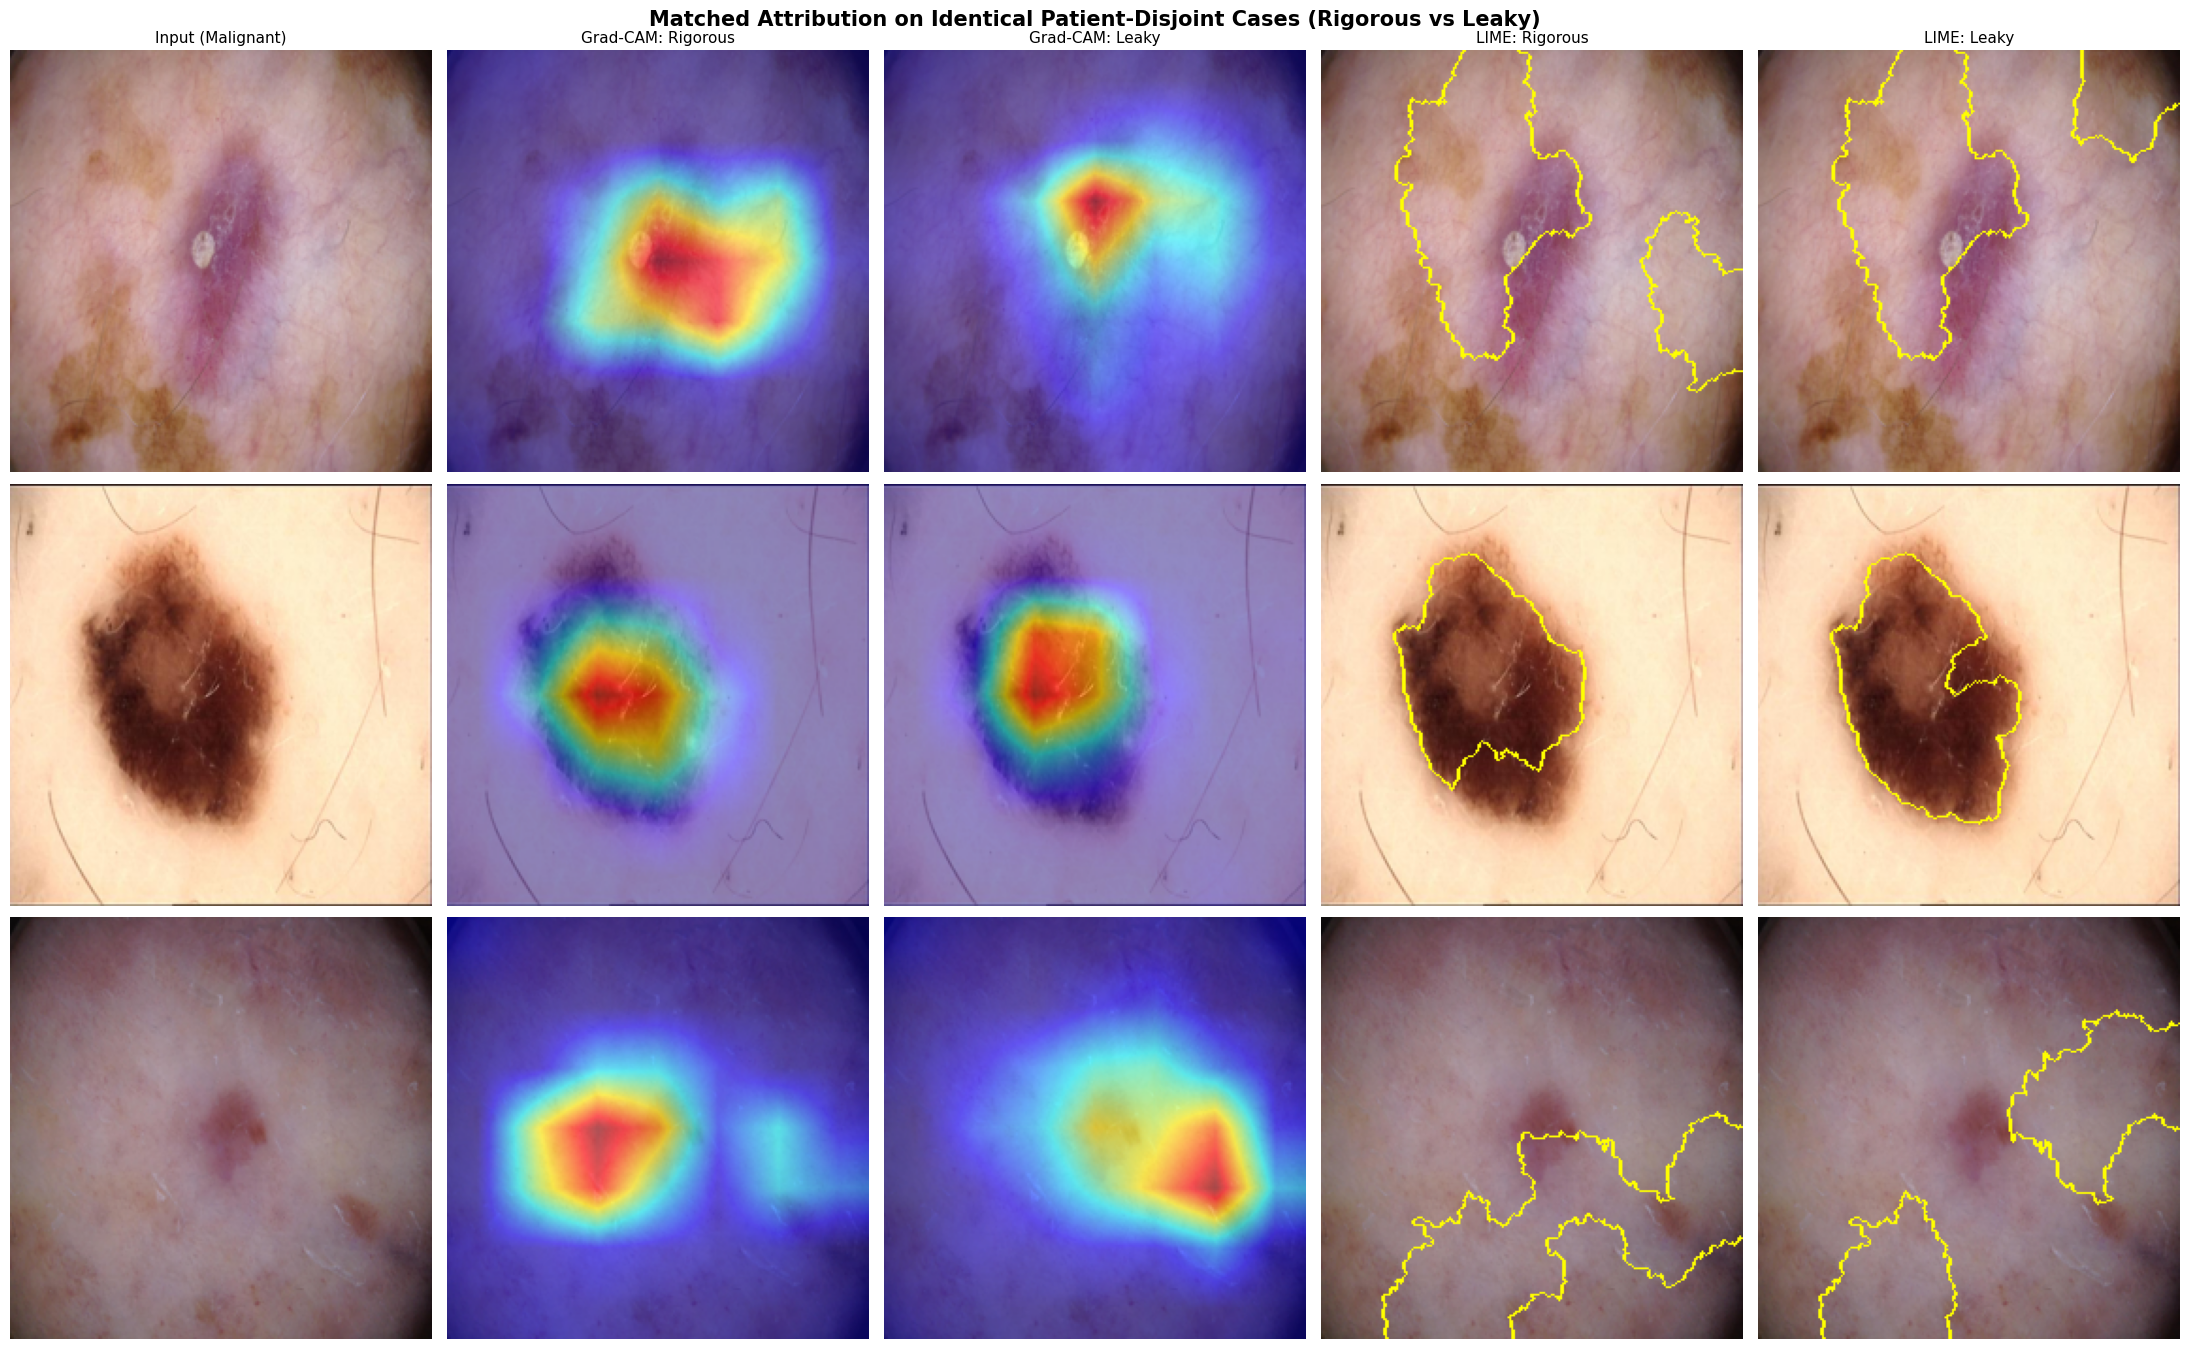


=== Peripheral (border) Grad-CAM mass: higher = more shortcut-like attention ===
  Rigorous model : 0.152
  Leaky model    : 0.199
  Delta (Leaky - Rigorous): +0.047
Add-on 1 complete -> addon1_matched_xai.png, addon1_border_ratio.csv


In [13]:
# ====== ADD-ON 1: MATCHED XAI (LEAKY vs RIGOROUS) ======
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from lime import lime_image
from skimage.segmentation import mark_boundaries
from PIL import Image

# Rigorous model = last patient-split fold (already trained); bring back to GPU
rig_m = PR[-1]['model'].to(DEVICE); rig_m.eval()

# Train (or resume) a MATCHED leaky (random-split) model on the last random fold
_ti, _ei = rkf[-1]
_trR = isic_df.iloc[_ti].reset_index(drop=True)
_teR = isic_df.iloc[_ei].reset_index(drop=True)
leaky_m = load_model_ckpt(mkmodel, 'addon1_leaky')
if leaky_m is None:
    print('Training matched leaky model for XAI...')
    leaky_res = train_arch(_trR, _teR, FOLDS, 'Leaky-XAI', mkmodel, keep_model=True)
    leaky_m = leaky_res['model']; save_model_ckpt(leaky_m, 'addon1_leaky')
    print('  saved checkpoint: addon1_leaky')
else:
    print('Loaded matched leaky XAI model from checkpoint')
leaky_m.eval()

# Same held-out malignant cases from the PATIENT test fold (unseen by rigorous model)
last_te = isic_df.iloc[gkf[-1][1]].reset_index(drop=True)
pos_pool = last_te[last_te.Label == 1]
n_show = min(3, len(pos_pool))
xai_df = pos_pool.sample(n_show, random_state=42).reset_index(drop=True)

base_r = rig_m.module if isinstance(rig_m, nn.DataParallel) else rig_m
base_l = leaky_m.module if isinstance(leaky_m, nn.DataParallel) else leaky_m
cam_r = GradCAM(model=rig_m, target_layers=[base_r.layer4[-1]])
cam_l = GradCAM(model=leaky_m, target_layers=[base_l.layer4[-1]])
lime_e = lime_image.LimeImageExplainer()
pred_r = make_lime_pred(rig_m); pred_l = make_lime_pred(leaky_m)

fig, axes = plt.subplots(n_show, 5, figsize=(22, 4.6*n_show))
if n_show == 1: axes = axes.reshape(1, -1)
cols = ['Input (Malignant)', 'Grad-CAM: Rigorous', 'Grad-CAM: Leaky', 'LIME: Rigorous', 'LIME: Leaky']
fig.suptitle('Matched Attribution on Identical Patient-Disjoint Cases (Rigorous vs Leaky)', fontsize=15, fontweight='bold')
rig_bord, leaky_bord = [], []
for i, (_, row) in enumerate(xai_df.iterrows()):
    img = Image.open(row.filepath).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    inp = np.array(img).astype(np.float32) / 255.0
    t = BT(img).unsqueeze(0).to(DEVICE)
    gcr = cam_r(input_tensor=t, targets=[ClassifierOutputTarget(1)])[0]
    gcl = cam_l(input_tensor=t, targets=[ClassifierOutputTarget(1)])[0]
    rig_bord.append(border_ratio(gcr)); leaky_bord.append(border_ratio(gcl))
    er = lime_e.explain_instance(inp.astype('double'), pred_r, top_labels=1, hide_color=0, num_samples=300)
    tr_, mr_ = er.get_image_and_mask(er.top_labels[0], positive_only=True, num_features=5, hide_rest=False)
    el = lime_e.explain_instance(inp.astype('double'), pred_l, top_labels=1, hide_color=0, num_samples=300)
    tl_, ml_ = el.get_image_and_mask(el.top_labels[0], positive_only=True, num_features=5, hide_rest=False)
    panels = [inp, show_cam_on_image(inp, gcr, use_rgb=True), show_cam_on_image(inp, gcl, use_rgb=True),
              mark_boundaries(tr_, mr_), mark_boundaries(tl_, ml_)]
    for j, pan in enumerate(panels):
        axes[i, j].imshow(pan); axes[i, j].axis('off')
        if i == 0: axes[i, j].set_title(cols[j], fontsize=11)
plt.tight_layout(); plt.savefig(OUT/'addon1_matched_xai.png', dpi=300, bbox_inches='tight'); plt.show()

print('\n=== Peripheral (border) Grad-CAM mass: higher = more shortcut-like attention ===')
print(f'  Rigorous model : {np.mean(rig_bord):.3f}')
print(f'  Leaky model    : {np.mean(leaky_bord):.3f}')
print(f'  Delta (Leaky - Rigorous): {np.mean(leaky_bord)-np.mean(rig_bord):+.3f}')
pd.DataFrame({'sample': range(1, n_show+1), 'border_rigorous': rig_bord, 'border_leaky': leaky_bord}).to_csv(OUT/'addon1_border_ratio.csv', index=False)

rig_m.to('cpu'); del leaky_m
if 'leaky_res' in globals(): del leaky_res
torch.cuda.empty_cache()
print('Add-on 1 complete -> addon1_matched_xai.png, addon1_border_ratio.csv')

### Add-on 2 - ConvNeXt-Tiny: architecture robustness

  ⏭  ConvNeXt fold 1 loaded from checkpoint (skipped retraining)
   >> training ConvNeXt-Patient F2 (tr=934 te=234) ...
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 177MB/s]


      ConvNeXt-Patient F2 epoch 1/12  valAUC=0.8817  (67s)
      ConvNeXt-Patient F2 epoch 2/12  valAUC=0.8994  (17s)
      ConvNeXt-Patient F2 epoch 3/12  valAUC=0.9016  (17s)
      ConvNeXt-Patient F2 epoch 4/12  valAUC=0.9141  (18s)
      ConvNeXt-Patient F2 epoch 5/12  valAUC=0.9240  (18s)
      ConvNeXt-Patient F2 epoch 6/12  valAUC=0.9121  (17s)
      ConvNeXt-Patient F2 epoch 7/12  valAUC=0.9059  (17s)
      ConvNeXt-Patient F2 epoch 8/12  valAUC=0.9117  (17s)
      ConvNeXt-Patient F2 early-stop at epoch 8
   [ConvNeXt-Patient F2] AUC=0.9240 ACC=0.8547 F1=0.8712
   >> training ConvNeXt-Leaky F2 (tr=934 te=234) ...
      ConvNeXt-Leaky F2 epoch 1/12  valAUC=0.9064  (17s)
      ConvNeXt-Leaky F2 epoch 2/12  valAUC=0.9269  (18s)
      ConvNeXt-Leaky F2 epoch 3/12  valAUC=0.9364  (18s)
      ConvNeXt-Leaky F2 epoch 4/12  valAUC=0.9242  (17s)
      ConvNeXt-Leaky F2 epoch 5/12  valAUC=0.9345  (17s)
      ConvNeXt-Leaky F2 epoch 6/12  valAUC=0.9382  (17s)
      ConvNeXt-Leaky F2 epoc

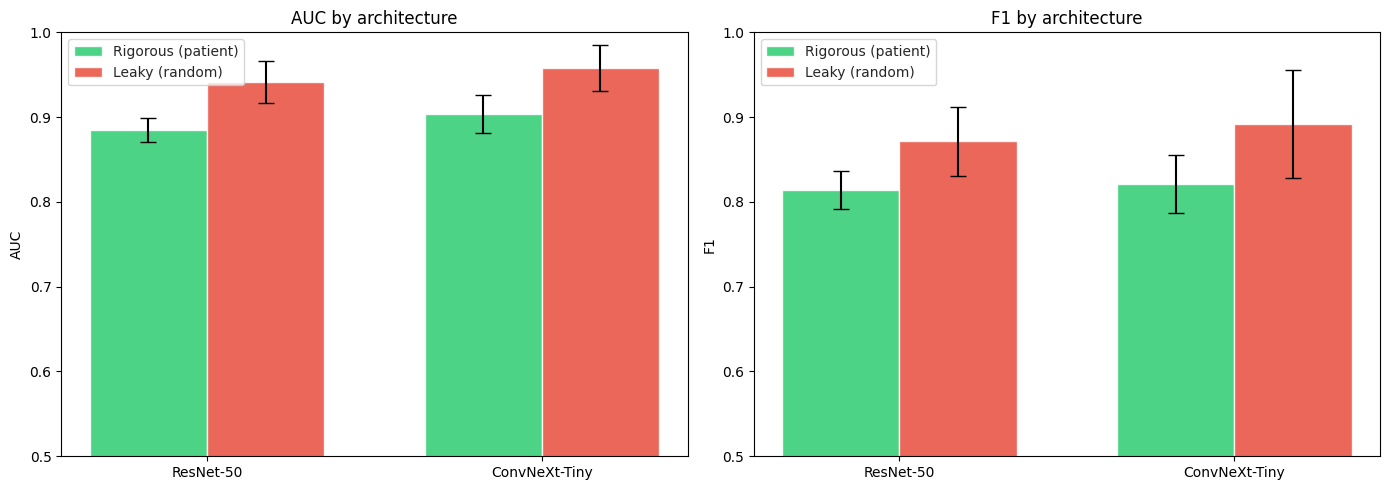

Add-on 2 complete -> addon2_architecture_comparison.{csv,png}


In [14]:
# ====== ADD-ON 2: CONVNEXT-TINY - FULL TWO-ARM PROTOCOL (resumable) ======
CN_PR, CN_RR = [], []
cn_yt, cn_pat, cn_ran = [], [], []
_t0 = time.time()
for f in range(FOLDS):
    if has_ckpt(f'addon2_fold{f+1}'):
        _c = load_pkl_ckpt(f'addon2_fold{f+1}')
        CN_PR.append(_c['rp']); CN_RR.append(_c['rr'])
        cn_yt.extend(_c['rp']['yt']); cn_pat.extend(_c['rp']['yp']); cn_ran.extend(_c['rr']['yp'])
        print(f'  \u23ed  ConvNeXt fold {f+1} loaded from checkpoint (skipped retraining)')
        continue
    ti, ei = gkf[f]
    trG = isic_df.iloc[ti].reset_index(drop=True); teG = isic_df.iloc[ei].reset_index(drop=True)
    if teG.Label.nunique() < 2:
        print(f'Fold {f+1}: single-class test, skipped'); continue
    rp = train_arch(trG, teG, f+1, 'ConvNeXt-Patient', mkmodel_convnext, keep_model=False)
    CN_PR.append(rp)
    ti2, ei2 = rkf[f]
    trR = isic_df.iloc[ti2].reset_index(drop=True); teR = isic_df.iloc[ei2].reset_index(drop=True)
    lm = train_arch(trR, teR, f+1, 'ConvNeXt-Leaky', mkmodel_convnext, keep_model=True, verbose=False)
    _, af, ac, f1f, ytf, ypf, yprf = evl(lm['model'], dl(teG, aug=False, sh=False))
    rr = dict(auc=af, acc=ac, f1=f1f, yt=ytf, yp=ypf, ypr=yprf)
    CN_RR.append(rr)
    del lm['model'], lm; torch.cuda.empty_cache()
    cn_yt.extend(rp['yt']); cn_pat.extend(rp['yp']); cn_ran.extend(ypf)
    save_pkl_ckpt({'rp': rp, 'rr': rr}, f'addon2_fold{f+1}')
    print(f'  Fold {f+1}: Patient AUC={rp["auc"]:.4f} | Leaky@PatientTest AUC={af:.4f}  (delta={af-rp["auc"]:+.4f})  [checkpoint saved]')
print(f'ConvNeXt two-arm protocol done in {(time.time()-_t0)/60:.1f} min')

def _agg(res_list, met): return ci95([r[met] for r in res_list])
rows = []
for met in ['auc', 'acc', 'f1']:
    for arch, prl, rrl in [('ResNet-50', PR, RR), ('ConvNeXt-Tiny', CN_PR, CN_RR)]:
        pm, pc = _agg(prl, met); rm, rc = _agg(rrl, met)
        rows.append(dict(Architecture=arch, Metric=met.upper(),
                         Rigorous=f'{pm:.4f}+/-{pc:.4f}', Leaky=f'{rm:.4f}+/-{rc:.4f}', Inflation=f'{rm-pm:+.4f}'))
cn_tab = pd.DataFrame(rows)
print('\n=== CROSS-ARCHITECTURE LEAKAGE INFLATION (ISIC) ===')
print(cn_tab.to_string(index=False))
cn_tab.to_csv(OUT/'addon2_architecture_comparison.csv', index=False)

from statsmodels.stats.contingency_tables import mcnemar
_yt = np.array(cn_yt); _pp = np.array(cn_pat); _rr = np.array(cn_ran)
_pc = (_pp == _yt); _rc = (_rr == _yt)
_tbl = [[int(np.sum(_pc & _rc)), int(np.sum(_pc & ~_rc))], [int(np.sum(~_pc & _rc)), int(np.sum(~_pc & ~_rc))]]
_mc = mcnemar(_tbl, exact=False, correction=True)
print(f'\nConvNeXt McNemar: chi2={_mc.statistic:.4f}  p={_mc.pvalue:.2e}  ->', 'SIGNIFICANT' if _mc.pvalue<0.05 else 'n.s.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5)); sns.set_style('whitegrid')
archs = ['ResNet-50', 'ConvNeXt-Tiny']; x = np.arange(len(archs)); w = 0.35
for k, met in enumerate(['auc', 'f1']):
    pr_m = [ci95([r[met] for r in PR])[0], ci95([r[met] for r in CN_PR])[0]]
    pr_c = [ci95([r[met] for r in PR])[1], ci95([r[met] for r in CN_PR])[1]]
    rr_m = [ci95([r[met] for r in RR])[0], ci95([r[met] for r in CN_RR])[0]]
    rr_c = [ci95([r[met] for r in RR])[1], ci95([r[met] for r in CN_RR])[1]]
    ax = axes[k]
    ax.bar(x-w/2, pr_m, w, yerr=pr_c, capsize=6, label='Rigorous (patient)', color='#2ecc71', alpha=0.85)
    ax.bar(x+w/2, rr_m, w, yerr=rr_c, capsize=6, label='Leaky (random)', color='#e74c3c', alpha=0.85)
    ax.set(xticks=x, xticklabels=archs, ylabel=met.upper(), title=f'{met.upper()} by architecture', ylim=[0.5, 1.0]); ax.legend()
plt.tight_layout(); plt.savefig(OUT/'addon2_architecture_comparison.png', dpi=300, bbox_inches='tight'); plt.show()
print('Add-on 2 complete -> addon2_architecture_comparison.{csv,png}')

### Add-on 3 - Leakage severity (dose-response)

   >> training Leaky-Severity F1 (tr=934 te=234) ...
      Leaky-Severity F1 epoch 1/12  valAUC=0.8503  (11s)
      Leaky-Severity F1 epoch 2/12  valAUC=0.8830  (11s)
      Leaky-Severity F1 epoch 3/12  valAUC=0.8776  (11s)
      Leaky-Severity F1 epoch 4/12  valAUC=0.8907  (11s)
      Leaky-Severity F1 epoch 5/12  valAUC=0.8909  (11s)
      Leaky-Severity F1 epoch 6/12  valAUC=0.8826  (11s)
      Leaky-Severity F1 epoch 7/12  valAUC=0.8665  (11s)
      Leaky-Severity F1 epoch 8/12  valAUC=0.8690  (11s)
      Leaky-Severity F1 early-stop at epoch 8
   [Leaky-Severity F1] AUC=0.8909 ACC=0.8205 F1=0.8264
  Fold 1: 234 test images scored [checkpoint saved]
   >> training Leaky-Severity F2 (tr=934 te=234) ...
      Leaky-Severity F2 epoch 1/12  valAUC=0.8836  (11s)
      Leaky-Severity F2 epoch 2/12  valAUC=0.9022  (11s)
      Leaky-Severity F2 epoch 3/12  valAUC=0.8982  (11s)
      Leaky-Severity F2 epoch 4/12  valAUC=0.9041  (11s)
      Leaky-Severity F2 epoch 5/12  valAUC=0.8835  (11s)


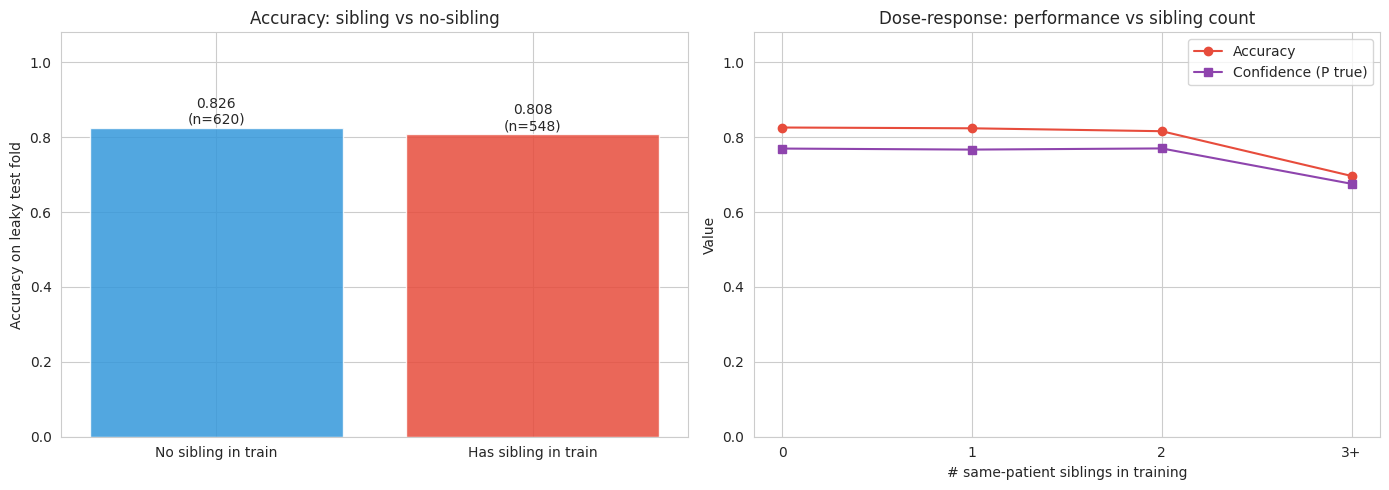

Add-on 3 complete -> addon3_leakage_severity.{csv,png}


In [15]:
# ====== ADD-ON 3: LEAKAGE SEVERITY ANALYSIS (dose-response, resumable) ======
from scipy.stats import spearmanr
sev_records = []
for f in range(FOLDS):
    if has_ckpt(f'addon3_fold{f+1}'):
        sev_records.extend(load_pkl_ckpt(f'addon3_fold{f+1}'))
        print(f'  \u23ed  Severity fold {f+1} loaded from checkpoint (skipped retraining)')
        continue
    ti2, ei2 = rkf[f]
    trR = isic_df.iloc[ti2].reset_index(drop=True)
    teR = isic_df.iloc[ei2].reset_index(drop=True)
    if teR.Label.nunique() < 2:
        continue
    lm = train_arch(trR, teR, f+1, 'Leaky-Severity', mkmodel, keep_model=True, verbose=True)
    _, _, _, _, yt, yp, ypr = evl(lm['model'], dl(teR, aug=False, sh=False))
    tc = trR.Patient_ID.value_counts()
    nsib = teR.Patient_ID.map(tc).fillna(0).astype(int).values
    labels = teR.Label.values.astype(int)
    prob_true = np.where(labels == 1, ypr, 1 - ypr)
    correct = (yp == labels).astype(int)
    fold_records = []
    for k in range(len(teR)):
        fold_records.append(dict(fold=f+1, label=int(labels[k]), n_train_siblings=int(nsib[k]),
                                 has_sibling=int(nsib[k] > 0), correct=int(correct[k]),
                                 prob_true=float(prob_true[k])))
    sev_records.extend(fold_records)
    save_pkl_ckpt(fold_records, f'addon3_fold{f+1}')
    print(f'  Fold {f+1}: {len(fold_records)} test images scored [checkpoint saved]')
    del lm['model'], lm; torch.cuda.empty_cache()

sev_df = pd.DataFrame(sev_records)
sev_df.to_csv(OUT/'addon3_leakage_severity.csv', index=False)

grp = sev_df.groupby('has_sibling').agg(n=('correct', 'size'), accuracy=('correct', 'mean'),
                                        mean_confidence=('prob_true', 'mean')).reset_index()
grp['group'] = grp['has_sibling'].map({0: 'No sibling in train', 1: 'Has sibling in train'})
print('\n=== LEAKAGE SEVERITY: siblinged vs non-siblinged test images ===')
print(grp[['group', 'n', 'accuracy', 'mean_confidence']].to_string(index=False))

rho_c, p_c = spearmanr(sev_df.n_train_siblings, sev_df.correct)
rho_p, p_p = spearmanr(sev_df.n_train_siblings, sev_df.prob_true)
print(f'\nSpearman  n_siblings vs correctness : rho={rho_c:+.3f}  p={p_c:.2e}')
print(f'Spearman  n_siblings vs confidence  : rho={rho_p:+.3f}  p={p_p:.2e}')

def _bucket(n):
    return '0' if n == 0 else ('1' if n == 1 else ('2' if n == 2 else '3+'))
sev_df['sib_bucket'] = sev_df.n_train_siblings.map(_bucket)
order = ['0', '1', '2', '3+']
buck = sev_df.groupby('sib_bucket').agg(accuracy=('correct', 'mean'), confidence=('prob_true', 'mean'),
                                        n=('correct', 'size')).reindex(order).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5)); sns.set_style('whitegrid')
ax = axes[0]
ax.bar(grp['group'], grp['accuracy'], color=['#3498db', '#e74c3c'], alpha=0.85)
for i, v in enumerate(grp['accuracy']):
    ax.text(i, v+0.01, f'{v:.3f}\n(n={int(grp.n.iloc[i])})', ha='center')
ax.set(ylabel='Accuracy on leaky test fold', title='Accuracy: sibling vs no-sibling', ylim=[0, 1.08])
ax = axes[1]
ax.plot(buck.index, buck['accuracy'], marker='o', color='#e74c3c', label='Accuracy')
ax.plot(buck.index, buck['confidence'], marker='s', color='#8e44ad', label='Confidence (P true)')
ax.set(xlabel='# same-patient siblings in training', ylabel='Value',
       title='Dose-response: performance vs sibling count', ylim=[0, 1.08]); ax.legend()
plt.tight_layout(); plt.savefig(OUT/'addon3_leakage_severity.png', dpi=300, bbox_inches='tight'); plt.show()
print('Add-on 3 complete -> addon3_leakage_severity.{csv,png}')

### Add-on 4 - Natural (imbalanced) prevalence

Imbalanced pool: 3584 images | 1455 patients | prevalence=0.163 (584 malignant)

Training RIGOROUS (patient-disjoint) arm...
   >> training NatImb-Patient F1 (tr=2843 te=741) ...
      NatImb-Patient F1 epoch 1/12  valAUC=0.8564  (126s)
      NatImb-Patient F1 epoch 2/12  valAUC=0.8652  (34s)
      NatImb-Patient F1 epoch 3/12  valAUC=0.8550  (33s)
      NatImb-Patient F1 epoch 4/12  valAUC=0.8816  (33s)
      NatImb-Patient F1 epoch 5/12  valAUC=0.8960  (33s)
      NatImb-Patient F1 epoch 6/12  valAUC=0.8921  (33s)
      NatImb-Patient F1 epoch 7/12  valAUC=0.8935  (33s)
      NatImb-Patient F1 epoch 8/12  valAUC=0.8867  (33s)
      NatImb-Patient F1 early-stop at epoch 8
   [NatImb-Patient F1] AUC=0.8960 ACC=0.7989 F1=0.5706
  saved checkpoint: addon4_rigorous
Training LEAKY (random-split) arm...
   >> training NatImb-Leaky F1 (tr=2867 te=741) ...
      NatImb-Leaky F1 epoch 1/12  valAUC=0.8631  (33s)
      NatImb-Leaky F1 epoch 2/12  valAUC=0.9174  (34s)
      NatImb-Leaky F1 epoch 

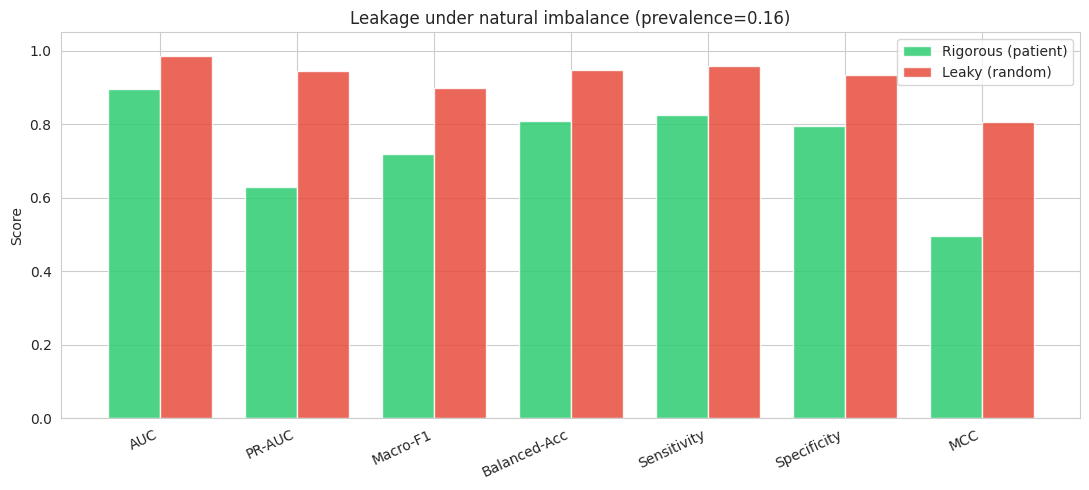

Add-on 4 complete -> addon4_natural_imbalance.{csv,png}


In [16]:
# ====== ADD-ON 4: NATURAL CLASS-IMBALANCE SETTING (resumable) ======
# Drop balanced subsampling: keep ALL malignant + benign at a low target prevalence
# to approximate deployment imbalance. Both arms use identical class-weighted training;
# only the SPLIT differs (patient-disjoint vs random). The leaky arm's random 80% may
# pull siblings/duplicates of test patients into training (the leakage under study).
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             balanced_accuracy_score, matthews_corrcoef, recall_score)

NAT_PREV = 0.10        # target positive prevalence
MAX_BENIGN = 3000      # cap for notebook tractability (raise toward natural ~1.7% if compute allows)

_full = pd.read_csv(CSV)
_full['Label'] = _full['target'].astype(int)
_full['Patient_ID'] = _full['patient_id'].astype(str)
_full['filepath'] = _full['image_name'].map(IDX)
_full = _full.dropna(subset=['filepath']).reset_index(drop=True)
_pos = _full[_full.Label == 1]; _neg = _full[_full.Label == 0]
_nb = min(len(_neg), MAX_BENIGN, int(len(_pos)*(1-NAT_PREV)/NAT_PREV))
nat = pd.concat([_pos, _neg.sample(_nb, random_state=SEED)]).sample(frac=1, random_state=SEED).reset_index(drop=True)
prev = nat.Label.mean()
print(f'Imbalanced pool: {len(nat)} images | {nat.Patient_ID.nunique()} patients | prevalence={prev:.3f} ({int(nat.Label.sum())} malignant)')

# Patient-disjoint test fold (shared by BOTH arms)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
_tr, _te = next(gss.split(nat, nat.Label, groups=nat.Patient_ID))
natG_tr = nat.iloc[_tr].reset_index(drop=True); natG_te = nat.iloc[_te].reset_index(drop=True)
# Leaky arm: random 80% of the whole pool
_rng = np.random.RandomState(SEED); _perm = _rng.permutation(len(nat)); _cut = int(0.8*len(nat))
natR_tr = nat.iloc[_perm[:_cut]].reset_index(drop=True)

def _cw(df):
    n = len(df); c = df.Label.value_counts()
    return torch.tensor([n/(2*max(int(c.get(0, 1)), 1)), n/(2*max(int(c.get(1, 1)), 1))],
                        dtype=torch.float32, device=DEVICE)

_rg = load_pkl_ckpt('addon4_rigorous')
if _rg is None:
    print('\nTraining RIGOROUS (patient-disjoint) arm...')
    nat_rig = train_arch(natG_tr, natG_te, 1, 'NatImb-Patient', mkmodel, class_weight=_cw(natG_tr), keep_model=True)
    _, _, _, _, ytg, ypg, yprg = evl(nat_rig['model'], dl(natG_te, aug=False, sh=False))
    save_pkl_ckpt({'yt': ytg, 'yp': ypg, 'ypr': yprg}, 'addon4_rigorous')
    del nat_rig['model'], nat_rig; torch.cuda.empty_cache()
    print('  saved checkpoint: addon4_rigorous')
else:
    ytg, ypg, yprg = _rg['yt'], _rg['yp'], _rg['ypr']; print('Loaded RIGOROUS arm from checkpoint')

_lk = load_pkl_ckpt('addon4_leaky')
if _lk is None:
    print('Training LEAKY (random-split) arm...')
    nat_lk = train_arch(natR_tr, natG_te, 1, 'NatImb-Leaky', mkmodel, class_weight=_cw(natR_tr), keep_model=True)
    _, _, _, _, ytl, ypl, yprl = evl(nat_lk['model'], dl(natG_te, aug=False, sh=False))
    save_pkl_ckpt({'yt': ytl, 'yp': ypl, 'ypr': yprl}, 'addon4_leaky')
    del nat_lk['model'], nat_lk; torch.cuda.empty_cache()
    print('  saved checkpoint: addon4_leaky')
else:
    ytl, ypl, yprl = _lk['yt'], _lk['yp'], _lk['ypr']; print('Loaded LEAKY arm from checkpoint')

def _imb_metrics(yt, yp, ypr):
    return {'AUC': roc_auc_score(yt, ypr), 'PR-AUC': average_precision_score(yt, ypr),
            'Macro-F1': f1_score(yt, yp, average='macro', zero_division=0),
            'Balanced-Acc': balanced_accuracy_score(yt, yp),
            'Sensitivity': recall_score(yt, yp, pos_label=1, zero_division=0),
            'Specificity': recall_score(yt, yp, pos_label=0, zero_division=0),
            'MCC': matthews_corrcoef(yt, yp)}
nat_tab = pd.DataFrame({'Rigorous (patient)': _imb_metrics(ytg, ypg, yprg),
                        'Leaky (random)': _imb_metrics(ytl, ypl, yprl)})
nat_tab['Inflation (Leaky-Rigorous)'] = nat_tab['Leaky (random)'] - nat_tab['Rigorous (patient)']
print(f'\n=== NATURAL-IMBALANCE RESULTS (prevalence={prev:.3f}) - same patient-disjoint test fold ===')
print(nat_tab.round(4).to_string())
nat_tab.to_csv(OUT/'addon4_natural_imbalance.csv')

fig, ax = plt.subplots(figsize=(11, 5)); sns.set_style('whitegrid')
mets = list(nat_tab.index); x = np.arange(len(mets)); w = 0.38
ax.bar(x-w/2, nat_tab['Rigorous (patient)'].values, w, label='Rigorous (patient)', color='#2ecc71', alpha=0.85)
ax.bar(x+w/2, nat_tab['Leaky (random)'].values, w, label='Leaky (random)', color='#e74c3c', alpha=0.85)
ax.set(xticks=x, xticklabels=mets, ylabel='Score', title=f'Leakage under natural imbalance (prevalence={prev:.2f})', ylim=[0, 1.05])
plt.setp(ax.get_xticklabels(), rotation=25, ha='right'); ax.legend()
plt.tight_layout(); plt.savefig(OUT/'addon4_natural_imbalance.png', dpi=300, bbox_inches='tight'); plt.show()
print('Add-on 4 complete -> addon4_natural_imbalance.{csv,png}')

### Bundle everything into one archive

In [17]:
# ====== BUNDLE ALL RESULTS (old base + all add-ons) ======
import glob, os, zipfile
ARCH = '/kaggle/working/ISIC_Final_Q1_Results_WITH_ADDONS.zip'
with zipfile.ZipFile(ARCH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for p in glob.glob(str(OUT) + '/**/*', recursive=True):
        if os.path.isfile(p):
            zf.write(p, os.path.relpath(p, '/kaggle/working'))
print('Final bundle written ->', ARCH)
print('Result files in', OUT, ':')
for p in sorted(glob.glob(str(OUT) + '/*.csv') + glob.glob(str(OUT) + '/*.png')):
    print('   ', os.path.basename(p))

Final bundle written -> /kaggle/working/ISIC_Final_Q1_Results_WITH_ADDONS.zip
Result files in /kaggle/working/q1_isic :
    __results___16_0.png
    __results___17_3.png
    __results___20_1.png
    __results___26_7.png
    addon1_border_ratio.csv
    addon1_matched_xai.png
    addon2_architecture_comparison.csv
    addon2_architecture_comparison.png
    addon3_leakage_severity.csv
    addon3_leakage_severity.png
    addon4_natural_imbalance.csv
    addon4_natural_imbalance.png
    comprehensive_analysis.png
    exhaustive_metrics.csv
    fig1_auc_mq.png
    fig2_xai.png
    results.csv
